# Lab #5: The Bias-Variance Trade-Off

In this lab, we discuss one of the most important concepts of machine learning, which is the bias-variance tradeoff. Although we use linear and polynomial regression as the machine learning models for this demonstration of the bias-variance trade-off, we can relate these methods to the dense feed-forward neural networks we have been using in the course.

As discussed earlier, linear regression can be written as a feed-forward neural network with no hidden layers and a linear activation function in the output node. Polynomial regression can be written as a dense feed-forward neural network with hidden layers using certain non-linear activation functions and a linear activation function in the output node. Increasing the degree of the polynomial regression model can be interpreted as increasing the number of hidden layers and/or units in the hidden layers. Thus, in the discussion below, we can think of linear regression as representing the simplest dense feed-forward neural network and higher-order polynomials as representing more complex dense feed-forward neural networks (with complexity increasing as the degree of the polynomial increases)

### Bias-Variance Trade-Off

Assume that we have a regression problem where we are trying to fit a model to capture the relationship between one feature (the independent variable, x) and the response. Furthermore, assume that we happen to know the true relationship, given by the polynomial f(x) = 6x^3 + 6x^2 − 12x, shown below.

In [15]:
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

random.seed(123)

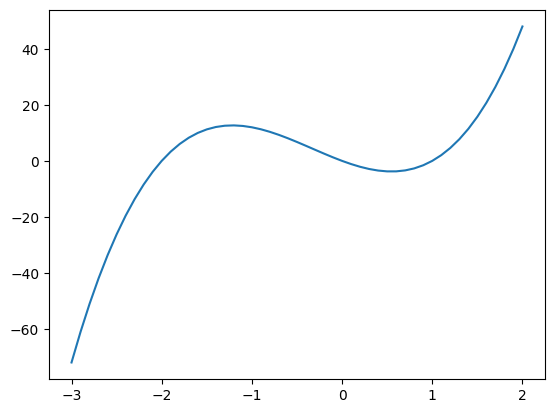

In [16]:
def true_relationship(x):
    return (6*x**3 + 6*x**2 - 12*x)


data = pd.DataFrame({'x': np.arange(-3, 2.1, 0.1)})
data['f'] = data['x'].apply(true_relationship)
plt.plot(data['x'], data['f'])

The response consists of noisy values of the true relationship taken at the observation locations x = −3,−2.9, . . . , 2. To simulate these noisy values, we add a normal random variable to each of the true relationship values.

In [17]:
def get_observation(x):
    return (6*x**3 + 6*x**2 - 12*x + random.gauss(0, 15))

data['label'] = data['x'].apply(get_observation)

Now, let’s try to capture the true relationship by fitting two polynomial regression models. The details behind polynomial regression are not important; it is enough to understand that a polynomial regression model seeks to find the best fitting polynomial, of a specified degree, to the data. We’ll use a linear regression model (i.e., a 1-degree polynomial regression model) and a 25-degree polynomial regression model. We fit the polynomial regression models to the data using scikit-learn.

In [18]:
# linear regression (degree = 1)
linear_model = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('linear', LinearRegression())
])
linear_model.fit(data[['x']], data[['label']])
data['lm_predictions'] = linear_model.predict(data[['x']])

# 25-degree polynomial regression (degree = 25)
high_order_model = Pipeline([
    ('poly', PolynomialFeatures(degree=25)),
    ('linear', LinearRegression())
])
high_order_model.fit(data[['x']], data[['label']])
data['high_order_predictions'] = high_order_model.predict(data[['x']])

The plot of the true relationship, the observations, the fitted linear regression model, and the fitted 25 degree polynomial regression model is shown below.

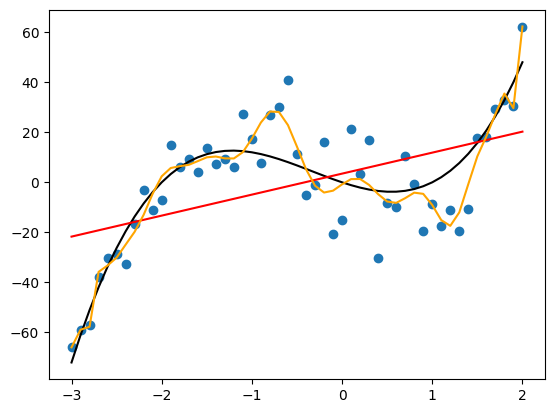

In [19]:
plt.plot(data['x'], data['f'], color = 'black')
plt.scatter(data['x'], data['label'])
plt.plot(data['x'], data['lm_predictions'], color = 'red')
plt.plot(data['x'], data['high_order_predictions'], color = 'orange')

From this plot, we can clearly see that neither regression model does an adequate job at capturing the true relationship. The linear regression model makes the assumption that the true relationship is linear, so it is not flexible enough and results in a model that cannot capture the structure of the relationship. Conversely, the 25-degree polynomial regression model makes the assumption that the true relationship is highly nonlinear, so it is too flexible and results in a model that is simply trying to match the observations instead of learning the structure of the relationship.

Now we will focus on the predictions that each model makes at x = 1. Note the positions of these predictions on the plot above, since we will now use a new set of noisy values taken at the same observation locations x = −3,−2.9, . . . , 2 to build the polynomial regression models.

In [20]:
data['new_label'] = data['x'].apply(get_observation)

In [21]:
# linear regression (degree = 1)
linear_model_new = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('linear', LinearRegression())
])
linear_model_new.fit(data[['x']], data[['new_label']])
data['lm_predictions_new'] = linear_model_new.predict(data[['x']])

# 25-degree polynomial regression (degree = 25)
high_order_model_new = Pipeline([
    ('poly', PolynomialFeatures(degree=25)),
    ('linear', LinearRegression())
])
high_order_model_new.fit(data[['x']], data[['new_label']])
data['high_order_predictions_new'] = high_order_model_new.predict(data[['x']])

The behavior of the new polynomial regression models, shown below, is the same as when we used the previous data. Namely, the linear regression model is not flexible enough and the 25-degree polynomial model is too flexible.

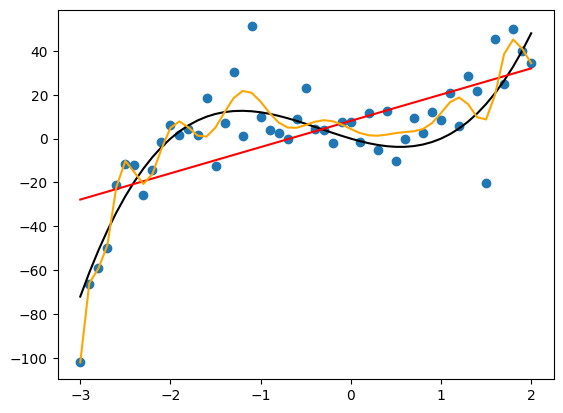

In [22]:
plt.plot(data['x'], data['f'], color = 'black')
plt.scatter(data['x'], data['new_label'])
plt.plot(data['x'], data['lm_predictions_new'], color = 'red')
plt.plot(data['x'], data['high_order_predictions_new'], color = 'orange')

If we compare the predictions at x = 1 from both sets of polynomial regression models, we make the following observations:

1. The predictions from the two linear regression models are similar. Furthermore, the center of both predictions is not close to the value of the true relationship at x = 1.

2. The predictions from the two 25-degree polynomial regression models are very different. However, the center of both predictions is close to the value of the true relationship at x = 1. In other words, the predictions seem to be centered around the value of the true relationship.

The behavior of these predictions is due to the bias-variance trade-off: the predictions from the linear regression model have higher bias but lower variance, while the predictions from the 25-degree polynomial regression model have lower bias but higher variance. Bias is the difference between the average predictions of the model and the value of the true relationship. Here, the linear regression model has high bias, since it makes the assumption that the true relationship is linear and leads to a model that is too simple to capture the relationship. Variance is the amount of variability in the model predictions. Here, the 25-degree polynomial regression model has high variance since it tries to match the observations too closely, so even a slight change in the observations will lead to predictions that are very different.

In other words, the linear regression model pays very little attention to the observations, whereas the 25-degree polynomial regression model pays too close attention to the observations. A slight change in the observations will lead to a much larger change in the predictions of the 25-degree polynomial regression model than in the linear regression model.

To get more intuition behind the bias-variance trade-off, let’s perform the same experiment 500 times to get 500 predictions from each polynomial regression model at x = 1.

In [23]:
lm_predictions = []
high_order_predictions = []
for i in range(1, 500):
    data['temp_label'] = data['x'].apply(get_observation)
    # linear regression (degree = 1)
    linear_model_temp = Pipeline([
        ('poly', PolynomialFeatures(degree=1)),
        ('linear', LinearRegression())
    ])
    linear_model_temp.fit(data[['x']], data[['temp_label']])
    lm_predictions.append(linear_model_temp.predict(np.array([1]).reshape(1, -1)).item())
    
    # 25-degree polynomial regression (degree = 25)
    high_order_model_temp = Pipeline([
        ('poly', PolynomialFeatures(degree=25)),
        ('linear', LinearRegression())
    ])
    high_order_model_temp.fit(data[['x']], data[['temp_label']])
    high_order_predictions.append(high_order_model_temp.predict(np.array([1]).reshape(1, -1)).item())

results = pd.DataFrame({'x': 1, 'lm_predictions': lm_predictions, 'high_order_predictions': high_order_predictions})

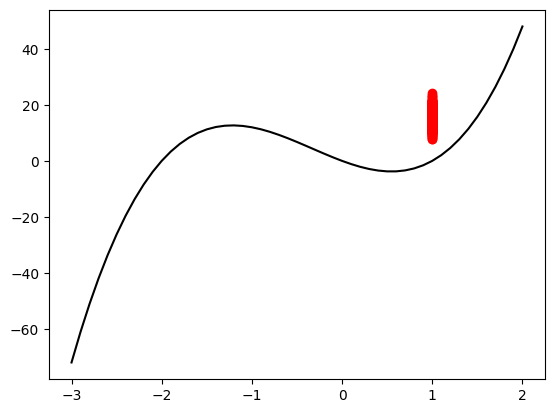

In [24]:
plt.plot(data['x'], data['f'], color = 'black')
plt.scatter(results['x'], results['lm_predictions'], color = 'red')

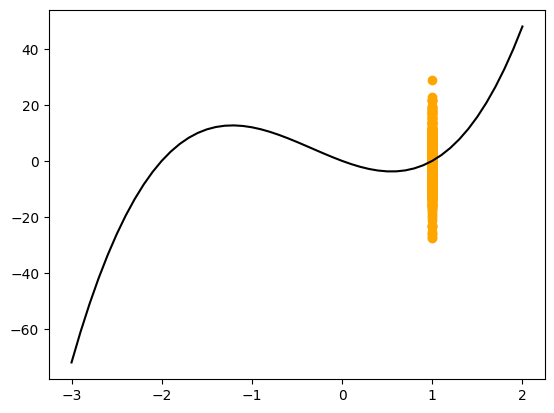

In [25]:
plt.plot(data['x'], data['f'], color = 'black')
plt.scatter(results['x'], results['high_order_predictions'], color = 'orange')

Now, we can clearly see the bias-variance trade-off: the predictions from the linear regression model (in red) are less dispersed, but are not centered around the value of the true relationship at x = 1, whereas the predictions from the 25-degree polynomial regression model (in orange) are more dispersed, but are centered around the value of the true relationship at x = 1.

To obtain the best polynomial regression model, we need to find a degree of polynomial between the two that manages the bias-variance trade-off. To do this, let’s fit polynomials with degrees ranging from 1 to 25 using the original labels. We’ll also use the original labels to evaluate the polynomials. The evaluation metric we use is called root mean squared error (RMSE), which measures how close the model predictions are to the observed values (i.e., labels). We want to minimize RMSE. The plot of RMSE for each of the polynomial regression models is shown below.

Text(0, 0.5, 'RMSE')

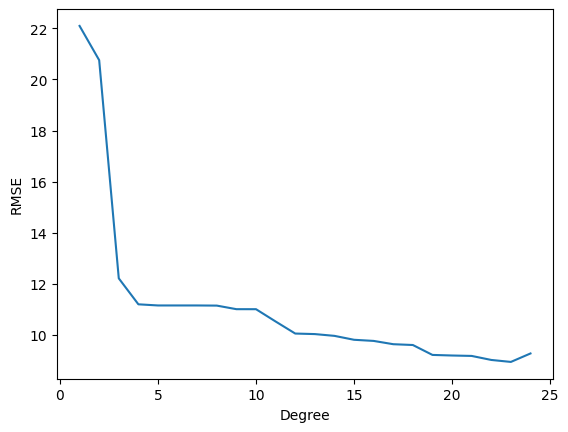

In [26]:
rmse = []
for degree in range(1, 25):
    temp_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])
    temp_model.fit(data[['x']], data[['label']])
    data['temp_predictions'] = temp_model.predict(data[['x']])
    rmse.append(np.mean((data['temp_predictions'] - data['label'])**2)**0.5)

plt.plot(range(1, 25), rmse)
plt.xlabel("Degree")
plt.ylabel("RMSE")

From this plot, the best models appear to be the polynomials of highest degree, since they result in a lower RMSE. However, we need to remember that the higher-degree polynomials are simply trying to match the observations used to fit them (see the discussion above). Instead of fitting and evaluating the polynomial regression models on the same data, let’s fit them using the original labels and evaluate them using the new labels. The plot of RMSE for each of the polynomial regression models, now using the new labels to calculate RMSE, is shown below.

Text(0, 0.5, 'RMSE')

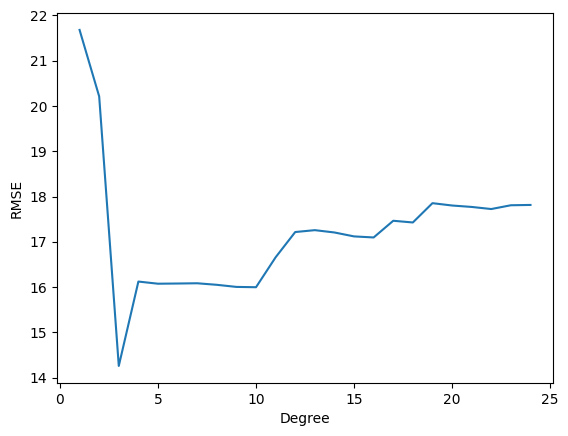

In [27]:
rmse = []
for degree in range(1, 25):
    temp_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])
    temp_model.fit(data[['x']], data[['label']])
    data['temp_predictions'] = temp_model.predict(data[['x']])
    rmse.append(np.mean((data['temp_predictions'] - data['new_label'])**2)**0.5)

plt.plot(range(1, 25), rmse)
plt.xlabel("Degree")
plt.ylabel("RMSE")

Now, we see very different behavior.

## Exercises

1. Why do the two RMSE plots show very different behavior? Use underfitting and overfitting in your answer, as well as the bias-variance tradeoff.

The first RMSE plot shows the prediction performance of different degree polynomials that were fit to the same data. In this case, the RMSE improves as the polynomial degree increases, but this is a result of the models overfitting to the data. On the contrary, the second RMSE plot displays the prediction performance of different degree polynomials on novel data. The conclusion that can be drawn from this plot is that the RMSE begins to increase after degree 3, which is an indication that the models are overfitting and becoming worse predictors of general data.

Prediction on novel data is a very clear indicator of the bias-variance tradeoff. The optimal model would have both low dispersion about the true value for a random set of input data, but also a dispersion that is centered about the true value. For polynomial degrees less than 3, the model is underfitting the data. This results in low dispersion, but prediction inaccuracy. For degrees greater than 3, the dispersion would proportionally increase, but the dispersion would be centered about the true value.

2. Using the last plot above, what degree of polynomial should we choose? After running all of the above code, substitute the degree you chose for the question mark in the code below and run it. Copy and paste the resulting plot.

The optimal degree polynomial is 3. This had the lowest RMSE on novel data, implying that both dispersion and accuracy for this model were optimal over the range of the data.

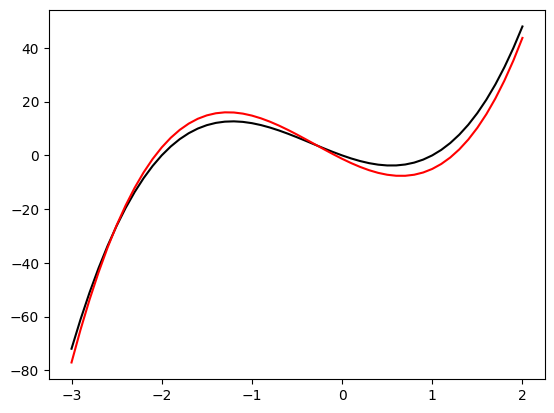

In [29]:
exercise_model = Pipeline([
        ('poly', PolynomialFeatures(degree=3)),
        ('linear', LinearRegression())
    ])
exercise_model.fit(data[['x']], data[['label']])
data['exercise_predictions'] = exercise_model.predict(data[['x']])
plt.plot(data['x'], data['f'], color = 'black')
plt.plot(data['x'], data['exercise_predictions'], color = 'red')